**PARTE PREVIA**

A continuaci?n realizaremos un estudio sobre los datasets subidos para realizar el trabajo pr?ctico (en adelante TP). En este notebook nos concentramos en el dataset de colaboraciones de CONICET 2023-2024 y en el archivo de posiciones asociado (`conicet_pos.pkl`).

El objetivo es caracterizar la red de coautor?as, analizar sus m?tricas principales, visualizar su estructura, estudiar centralidades, comunidades, ?reas de investigaci?n, robustez y compararla con una red aleatoria equivalente.

**INFORMACI?N SOBRE LOS DATOS**

*  C. elegans: Una red dirigida y pesada que representa la red de conexiones neuronales en el organismo Caenorhabditis elegans.

*  Facebook: Una red no dirigida y no pesada de c?rculos de Facebook. Cada nodo es un perfil de Facebook y un enlace significa que los perfiles son amigos en Facebook.

*  Email-EU: Una red no dirigida y no pesada de contactos v?a e-mail en una instituci?n europea de investigaci?n.

*  Aeropuertos: Una red dirigida y pesada. Cada nodo es un aeropuerto de Estados Unidos y los enlaces representan vuelos.

*  CONICET: Una red no dirigida de colaboraciones acad?micas. Cada nodo es un autor de un subconjunto de publicaciones del CONICET entre 2023 y 2024, y cada enlace representa una colaboraci?n entre autores. El archivo GraphML incluye metadatos de ?reas de investigaci?n (`A1`, `A2`, `A3`) y un atributo `weight` en las aristas.

**SET DE INDICADORES PARA REALIZAR EL AN?LISIS E INSPECCI?N DEL DATASET**

*  Caracter?sticas de la red: es dirigida?, es pesada?, es conectada?
*  An?lisis de componente gigante y eliminaci?n de autoenlaces.
*  Visualizaci?n espacial/topol?gica usando el archivo `conicet_pos.pkl`.
*  Distribuci?n de grados y pesos de colaboraci?n.
*  Coeficiente de clustering.
*  Coeficiente de transitividad.
*  Coeficiente de asortatividad.
*  Distancias m?nimas medias.
*  Centralidades: grado, fuerza, intermediaci?n y PageRank.
*  An?lisis por ?reas de investigaci?n (`A1`, `A2`, `A3`).
*  Detecci?n de comunidades.
*  Robustez frente a eliminaci?n aleatoria y ataques dirigidos.
*  Comparaci?n con una red aleatoria de Erd?s-R?nyi.

**CARGANDO LIBRER?AS Y ARCHIVOS**

In [1]:
# Instalar dependencias necesarias antes de ejecutar el an?lisis.
# En Colab o Jupyter, correr esta celda una vez si aparece ModuleNotFoundError.
%pip install -q matplotlib numpy pandas scipy networkx python-louvain

In [2]:
import os
import sys
import pickle
import subprocess
import importlib.util
from pathlib import Path

required_packages = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "scipy": "scipy",
    "networkx": "networkx",
    "community": "python-louvain",
}

missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    print("Instalando dependencias faltantes:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import community.community_louvain as cl

plt.rcParams["figure.figsize"] = (10, 7)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

In [3]:
# Esta celda permite correr el notebook tanto en Colab/Drive como en local.
# Si no encuentra los datos, descarga datasets-tp1.zip y lo descomprime autom?ticamente.
import zipfile
import urllib.request

DATASET_URL = "https://www.dropbox.com/scl/fi/ke7kyfox7w6hnmcnt3x2b/datasets-tp1.zip?rlkey=m7uljexxrljs6bu9pcv8qtyh7&st=09rgvayp&dl=1"
ZIP_PATH = Path("datasets-tp1.zip")

CONICET_GRAPHML_NAME = "colaboracionesCONICET_2023_2024_filtrado.graphml"
CONICET_POS_NAME = "conicet_pos.pkl"
required_files = [CONICET_GRAPHML_NAME, CONICET_POS_NAME]


def has_conicet_files(directory):
    return directory.exists() and all((directory / file_name).exists() for file_name in required_files)


def find_conicet_data_dir():
    candidate_dirs = [
        Path("datasets-tp1"),
        Path("../datasets-tp1"),
        Path("."),
        Path("Insumos"),
        Path("insumos"),
        Path("../Insumos"),
        Path("../insumos"),
        Path("Insumos/datasets-tp1"),
        Path("insumos/datasets-tp1"),
        Path("../Insumos/datasets-tp1"),
        Path("../insumos/datasets-tp1"),
        Path("/content/drive/MyDrive/Insumos"),
        Path("/content/drive/MyDrive/Insumos/datasets-tp1"),
        Path("/content/drive/MyDrive/insumos"),
        Path("/content/drive/MyDrive/insumos/datasets-tp1"),
        Path("/content/drive/MyDrive/TP1/datasets-tp1"),
    ]

    for candidate in candidate_dirs:
        if has_conicet_files(candidate):
            return candidate

    return None


def download_and_extract_datasets():
    print("No encontr? los datos de CONICET. Descargando datasets-tp1.zip...")
    urllib.request.urlretrieve(DATASET_URL, ZIP_PATH)

    print("Descomprimiendo datasets-tp1.zip...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(Path("."))

    data_dir = find_conicet_data_dir()
    if data_dir is None:
        raise FileNotFoundError(
            "Descargu? el zip, pero no encontr? el GraphML de CONICET y conicet_pos.pkl. "
            "Revisar la estructura del archivo descomprimido."
        )
    return data_dir


DATA_DIR = find_conicet_data_dir()

if DATA_DIR is None:
    DATA_DIR = download_and_extract_datasets()

CONICET_GRAPHML = DATA_DIR / CONICET_GRAPHML_NAME
CONICET_POSITIONS = DATA_DIR / CONICET_POS_NAME

print("Directorio de datos:", DATA_DIR.resolve())
print("Archivo GraphML:", CONICET_GRAPHML)
print("Archivo de posiciones:", CONICET_POSITIONS)

No encontr? los datos de CONICET. Descargando datasets-tp1.zip...
Descomprimiendo datasets-tp1.zip...
Directorio de datos: /content
Archivo GraphML: colaboracionesCONICET_2023_2024_filtrado.graphml
Archivo de posiciones: conicet_pos.pkl


## CONICET

Realizamos la carga del dataset de CONICET. El archivo GraphML contiene la red de coautor?as y metadatos de ?rea para cada autor. Como el grafo representa colaboraciones, trabajamos con una red no dirigida. El atributo `weight`, cuando aparece, puede interpretarse como intensidad o cantidad de colaboraciones entre dos autores.

In [4]:
# Cargar grafo de colaboraciones CONICET
C = nx.read_graphml(CONICET_GRAPHML)

# Aseguramos que los pesos sean num?ricos cuando est?n presentes.
for _, _, data in C.edges(data=True):
    if "weight" in data:
        data["weight"] = float(data["weight"])

print(C)
print("Nodos:", C.number_of_nodes())
print("Aristas:", C.number_of_edges())
print("Autoenlaces:", nx.number_of_selfloops(C))

Graph with 8288 nodes and 14105 edges
Nodos: 8288
Aristas: 14105
Autoenlaces: 0


In [5]:
# Cargar posiciones precalculadas para visualizar la red
with open(CONICET_POSITIONS, "rb") as f:
    pos_conicet = pickle.load(f)

# Nos quedamos con posiciones de nodos presentes en el grafo.
pos_conicet = {str(n): tuple(coords) for n, coords in pos_conicet.items() if str(n) in C.nodes}

print("Nodos con posici?n:", len(pos_conicet))
print("Ejemplo de posici?n:", next(iter(pos_conicet.items())))

Nodos con posici?n: 8288
Ejemplo de posici?n: ('n0', (np.float64(0.25671915803140466), np.float64(-0.24156046565692835)))


In [6]:
# Veamos una muestra de metadatos de nodos
nodes_df = pd.DataFrame.from_dict(dict(C.nodes(data=True)), orient="index")
nodes_df.index.name = "node"
nodes_df.head()

,A1,A2,A3,author_key
node,,,,
n0,Paleontología,Ciencias de la Tierra y relacionadas con el Me...,Ciencias Naturales Y Exactas,id_51106
n1,"Filosofía, Historia y Filosofía de la Ciencia ...","Filosofía, Ética y Religión",Humanidades,id_1197
n2,Otras Ciencias Biológicas,Ciencias Biológicas,Ciencias Naturales Y Exactas,id_4948
n3,"Biología Celular, Microbiología",Ciencias Biológicas,Ciencias Naturales Y Exactas,id_50891
n4,"Ciencias de las Plantas, Botánica",Ciencias Biológicas,Ciencias Naturales Y Exactas,id_91182


In [7]:
# Vista r?pida de las primeras aristas
edges_df = nx.to_pandas_edgelist(C)
edges_df.head()

,source,target,weight,id
0,n0,n4689,1.266667,e0
1,n0,n6346,0.883333,e1
2,n0,n1896,0.950000,e2
3,n0,n2648,2.650000,e3
4,n0,n1141,0.600000,e4


**DIAGN?STICO GENERAL DEL GRAFO**

In [8]:
def diagnostico_grafo(G, nombre):
    print(f"--- Diagn?stico: {nombre} ---")
    print(G)

    dirigido = nx.is_directed(G)
    print(f"?Es dirigido?: {dirigido}")

    es_pesado = any("weight" in data for _, _, data in G.edges(data=True))
    print(f"?Tiene atributo de peso?: {es_pesado}")

    if dirigido:
        print(f"?Es conexo d?bil?: {nx.is_weakly_connected(G)}")
        print(f"?Es conexo fuerte?: {nx.is_strongly_connected(G)}")
    else:
        print(f"?Es conectado?: {nx.is_connected(G)}")

    print("N?mero de componentes:", nx.number_connected_components(G.to_undirected()))
    print("Densidad:", nx.density(G))
    print()

diagnostico_grafo(C, "Red de colaboraciones CONICET")

--- Diagn?stico: Red de colaboraciones CONICET ---
Graph with 8288 nodes and 14105 edges
?Es dirigido?: False
?Tiene atributo de peso?: True
?Es conectado?: False
N?mero de componentes: 5
Densidad: 0.00041072960253604637



La red de CONICET se interpreta como un grafo de colaboraci?n cient?fica: los nodos representan autores y los enlaces representan publicaciones en com?n. La presencia de varias componentes es esperable en redes acad?micas, porque no todas las ?reas o grupos de investigaci?n colaboran entre s?.

**LIMPIEZA Y COMPONENTE GIGANTE**

In [9]:
# Copia de trabajo para no modificar el grafo original
C_clean = C.copy()

# Eliminar autoenlaces si existieran
n_loops = nx.number_of_selfloops(C_clean)
C_clean.remove_edges_from(nx.selfloop_edges(C_clean))

# Componente gigante
largest_cc = max(nx.connected_components(C_clean), key=len)
C_main = C_clean.subgraph(largest_cc).copy()

print("Nodos grafo original:", C.number_of_nodes())
print("Aristas grafo original:", C.number_of_edges())
print("Autoenlaces eliminados:", n_loops)
print("Componentes:", nx.number_connected_components(C_clean))
print("Nodos componente gigante:", C_main.number_of_nodes())
print("Aristas componente gigante:", C_main.number_of_edges())
print("Porcentaje de nodos en componente gigante:", round(100 * C_main.number_of_nodes() / C_clean.number_of_nodes(), 2))
print("?Componente gigante conectada?:", nx.is_connected(C_main))

Nodos grafo original: 8288
Aristas grafo original: 14105
Autoenlaces eliminados: 0
Componentes: 5
Nodos componente gigante: 7714
Aristas componente gigante: 13030
Porcentaje de nodos en componente gigante: 93.07
?Componente gigante conectada?: True


La componente gigante concentra la parte principal de la red conectada. Para m?tricas que requieren conectividad, como distancia media o di?metro, trabajamos sobre esta componente principal.

**M?TRICAS GLOBALES**

In [10]:
degrees = dict(C_clean.degree())
weighted_degrees = dict(C_clean.degree(weight="weight"))
degree_values = np.array(list(degrees.values()))
weighted_degree_values = np.array(list(weighted_degrees.values()))

# Algunas m?tricas exactas pueden tardar en grafos grandes; las dejamos expl?citas para el TP.
metrics = {
    "nodos": C_clean.number_of_nodes(),
    "aristas": C_clean.number_of_edges(),
    "grado_promedio": degree_values.mean(),
    "grado_mediano": np.median(degree_values),
    "grado_maximo": degree_values.max(),
    "fuerza_promedio": weighted_degree_values.mean(),
    "fuerza_maxima": weighted_degree_values.max(),
    "densidad": nx.density(C_clean),
    "clustering_promedio": nx.average_clustering(C_clean),
    "clustering_ponderado": nx.average_clustering(C_clean, weight="weight"),
    "transitividad": nx.transitivity(C_clean),
    "asortatividad": nx.degree_assortativity_coefficient(C_clean),
    "distancia_media_componente_gigante": nx.average_shortest_path_length(C_main),
    "diametro_componente_gigante": nx.diameter(C_main),
}

pd.Series(metrics).to_frame("valor")

,valor
nodos,8288.000000
aristas,14105.000000
grado_promedio,3.403716
grado_mediano,2.000000
grado_maximo,34.000000
fuerza_promedio,2.755403
fuerza_maxima,42.233785
densidad,0.000411
clustering_promedio,0.575300
clustering_ponderado,0.035978


Estas m?tricas resumen la estructura global. El grado mide cu?ntos colaboradores tiene cada autor, mientras que la fuerza suma los pesos de sus colaboraciones. La distancia media permite estimar cu?ntos pasos de coautor?a separan, en promedio, a dos autores dentro de la componente gigante.

**DISTRIBUCI?N DE GRADO Y FUERZA**

In [11]:
centrality_base_df = pd.DataFrame({
    "node": list(C_clean.nodes()),
    "degree": [degrees[n] for n in C_clean.nodes()],
    "strength": [weighted_degrees[n] for n in C_clean.nodes()],
    "A1": [C_clean.nodes[n].get("A1") for n in C_clean.nodes()],
    "A2": [C_clean.nodes[n].get("A2") for n in C_clean.nodes()],
    "A3": [C_clean.nodes[n].get("A3") for n in C_clean.nodes()],
    "author_key": [C_clean.nodes[n].get("author_key") for n in C_clean.nodes()],
}).sort_values("degree", ascending=False)

centrality_base_df.head(10)

,node,degree,strength,A1,A2,A3,author_key
4300,n4300,34,42.233785,"Oceanografía, Hidrología, Recursos Hídricos",Ciencias de la Tierra y relacionadas con el Me...,Ciencias Naturales Y Exactas,id_15086
5732,n5732,34,30.655107,Ecología,Ciencias Biológicas,Ciencias Naturales Y Exactas,id_25043
447,n447,32,30.436447,Otras Ciencias Veterinarias,Ciencias Veterinarias,Ciencias Agrícolas,id_3759
0,n0,23,27.528571,Paleontología,Ciencias de la Tierra y relacionadas con el Me...,Ciencias Naturales Y Exactas,id_51106
3481,n3481,22,18.234138,Paleontología,Ciencias de la Tierra y relacionadas con el Me...,Ciencias Naturales Y Exactas,id_68060
3054,n3054,21,24.609432,Geología,Ciencias de la Tierra y relacionadas con el Me...,Ciencias Naturales Y Exactas,id_21914
4360,n4360,21,16.260353,Silvicultura,"Agricultura, Silvicultura y Pesca",Ciencias Agrícolas,id_36116
2040,n2040,20,15.608874,"Ciencias de las Plantas, Botánica",Ciencias Biológicas,Ciencias Naturales Y Exactas,id_2574
3874,n3874,20,28.423145,"Ciencias de las Plantas, Botánica",Ciencias Biológicas,Ciencias Naturales Y Exactas,id_24052
2628,n2628,20,22.958333,Otras Psicología,Psicología,Ciencias Sociales,id_25843


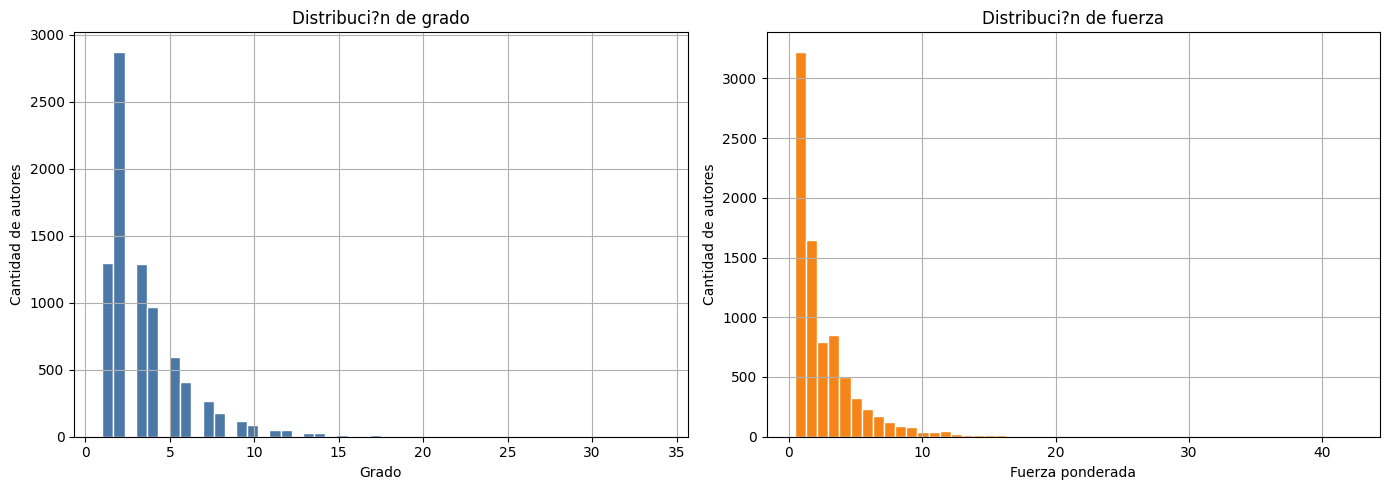

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(degree_values, bins=50, color="#4C78A8", edgecolor="white")
axes[0].set_title("Distribuci?n de grado")
axes[0].set_xlabel("Grado")
axes[0].set_ylabel("Cantidad de autores")

axes[1].hist(weighted_degree_values, bins=50, color="#F58518", edgecolor="white")
axes[1].set_title("Distribuci?n de fuerza")
axes[1].set_xlabel("Fuerza ponderada")
axes[1].set_ylabel("Cantidad de autores")

plt.tight_layout()
plt.show()

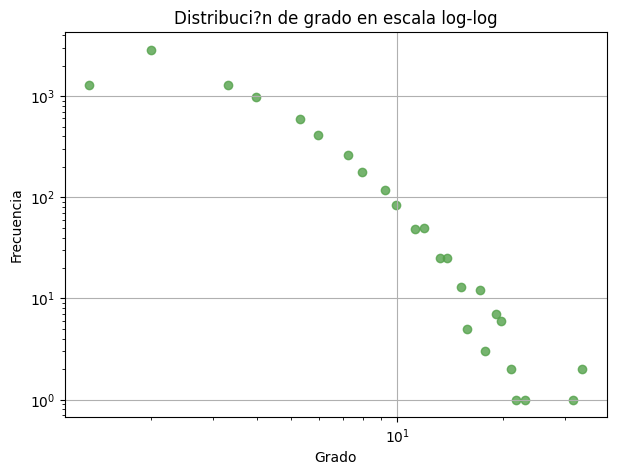

In [13]:
hist, bin_edges = np.histogram(degree_values, bins=50)
centers = (bin_edges[:-1] + bin_edges[1:]) / 2
mask = hist > 0

plt.figure(figsize=(7, 5))
plt.scatter(centers[mask], hist[mask], color="#54A24B", alpha=0.8)
plt.xscale("log")
plt.yscale("log")
plt.title("Distribuci?n de grado en escala log-log")
plt.xlabel("Grado")
plt.ylabel("Frecuencia")
plt.show()

En redes de colaboraci?n suele haber heterogeneidad: muchos autores colaboran con pocos colegas y un grupo reducido concentra una cantidad mayor de v?nculos. La fuerza permite complementar esta lectura, porque distingue autores con muchas colaboraciones repetidas o de mayor intensidad.

**AN?LISIS POR ?REAS DE INVESTIGACI?N**

In [14]:
area_summary = (
    centrality_base_df
    .groupby("A3", dropna=False)
    .agg(
        autores=("node", "count"),
        grado_promedio=("degree", "mean"),
        fuerza_promedio=("strength", "mean"),
        grado_maximo=("degree", "max"),
    )
    .sort_values("autores", ascending=False)
)

area_summary

,autores,grado_promedio,fuerza_promedio,grado_maximo
A3,,,,
Ciencias Naturales Y Exactas,3234,3.613482,2.871917,34
Ciencias Sociales,2419,3.045060,2.588422,20
Humanidades,1356,3.146755,2.530183,20
Ingenierías y Tecnologías,598,3.590301,2.778524,19
Ciencias Agrícolas,471,4.218684,3.509519,32
Ciencias Médicas y de la Salud,209,3.612440,2.589194,19
"Biología Marina, Limnología",1,2.000000,1.000000,2


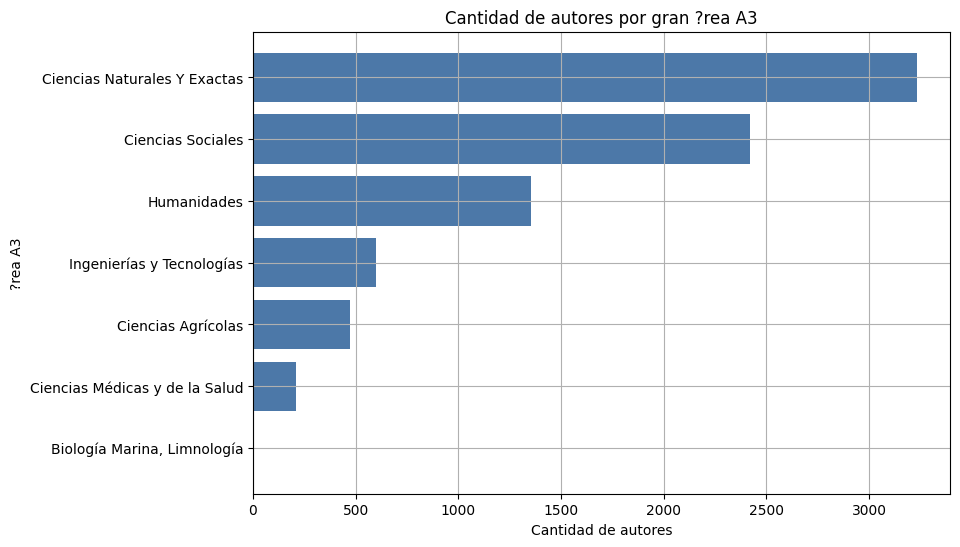

In [15]:
top_areas = area_summary.head(10).sort_values("autores")

plt.figure(figsize=(9, 6))
plt.barh(top_areas.index.astype(str), top_areas["autores"], color="#4C78A8")
plt.title("Cantidad de autores por gran ?rea A3")
plt.xlabel("Cantidad de autores")
plt.ylabel("?rea A3")
plt.show()

Los metadatos de ?rea permiten vincular la topolog?a de la red con la organizaci?n disciplinar. Si algunas ?reas tienen mayor grado promedio o mayor fuerza, eso puede indicar patrones de colaboraci?n m?s densos o grupos de investigaci?n m?s interconectados.

**CENTRALIDADES**

In [16]:
degree_centrality = nx.degree_centrality(C_clean)
pagerank = nx.pagerank(C_clean, alpha=0.85, weight="weight")

# La intermediaci?n exacta puede tardar; usamos una aproximaci?n para mantener el notebook ?gil.
betweenness = nx.betweenness_centrality(C_clean, k=500, seed=42, normalized=True, weight=None)

centrality_df = centrality_base_df.copy()
centrality_df["degree_centrality"] = centrality_df["node"].map(degree_centrality)
centrality_df["pagerank"] = centrality_df["node"].map(pagerank)
centrality_df["betweenness_aprox"] = centrality_df["node"].map(betweenness)

centrality_df.sort_values("pagerank", ascending=False).head(15)

,node,degree,strength,A1,A2,A3,author_key,degree_centrality,pagerank,betweenness_aprox
5732,n5732,34,30.655107,Ecología,Ciencias Biológicas,Ciencias Naturales Y Exactas,id_25043,0.004103,0.001074,0.128847
4300,n4300,34,42.233785,"Oceanografía, Hidrología, Recursos Hídricos",Ciencias de la Tierra y relacionadas con el Me...,Ciencias Naturales Y Exactas,id_15086,0.004103,0.000912,0.076077
3874,n3874,20,28.423145,"Ciencias de las Plantas, Botánica",Ciencias Biológicas,Ciencias Naturales Y Exactas,id_24052,0.002413,0.000849,0.014614
1510,n1510,17,25.600000,Otras Derecho,Derecho,Ciencias Sociales,id_35497,0.002051,0.000839,0.030028
3481,n3481,22,18.234138,Paleontología,Ciencias de la Tierra y relacionadas con el Me...,Ciencias Naturales Y Exactas,id_68060,0.002655,0.000826,0.008856
0,n0,23,27.528571,Paleontología,Ciencias de la Tierra y relacionadas con el Me...,Ciencias Naturales Y Exactas,id_51106,0.002775,0.000818,0.023239
447,n447,32,30.436447,Otras Ciencias Veterinarias,Ciencias Veterinarias,Ciencias Agrícolas,id_3759,0.003861,0.000794,0.008480
2509,n2509,19,15.333333,Otras Ingenierías y Tecnologías,Otras Ingenierías y Tecnologías,Ingenierías y Tecnologías,id_46101,0.002293,0.000748,0.004929
6332,n6332,20,20.055556,Otras Historia y Arqueología,Historia y Arqueología,Humanidades,id_43316,0.002413,0.000732,0.040271
2750,n2750,16,22.666667,"Ciencias de las Plantas, Botánica",Ciencias Biológicas,Ciencias Naturales Y Exactas,id_6441,0.001931,0.000680,0.004363


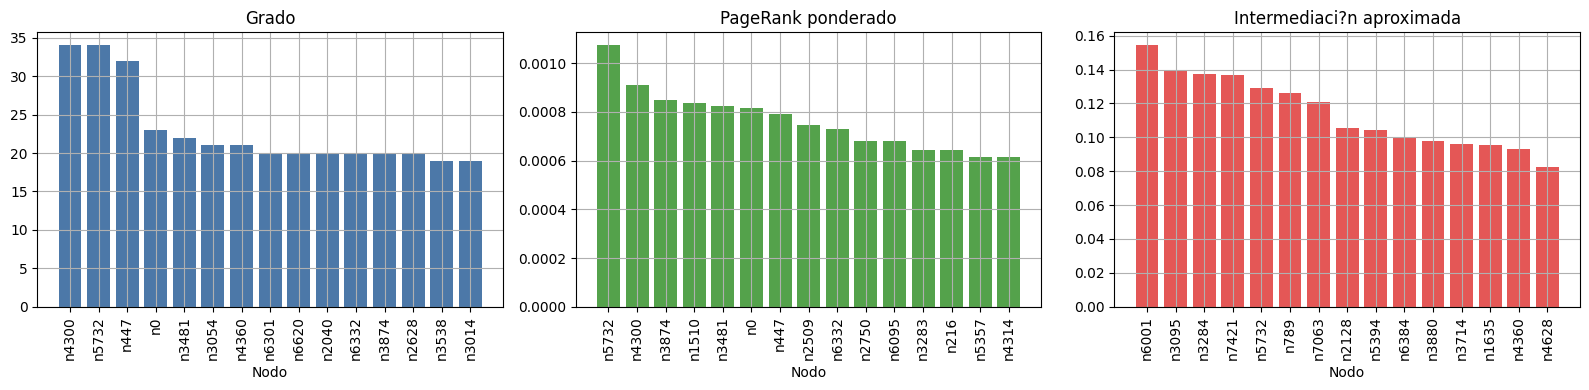

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col, title, color in zip(
    axes,
    ["degree", "pagerank", "betweenness_aprox"],
    ["Grado", "PageRank ponderado", "Intermediaci?n aproximada"],
    ["#4C78A8", "#54A24B", "#E45756"]
):
    top = centrality_df.sort_values(col, ascending=False).head(15)
    ax.bar(top["node"].astype(str), top[col], color=color)
    ax.set_title(title)
    ax.set_xlabel("Nodo")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

La centralidad de grado identifica autores con muchas colaboraciones directas. PageRank ponderado resalta autores conectados a otros autores relevantes y considera la intensidad de los v?nculos. La intermediaci?n aproxima qu? autores funcionan como puentes entre zonas o ?reas distintas de la red.

**VISUALIZACI?N DE LA RED**

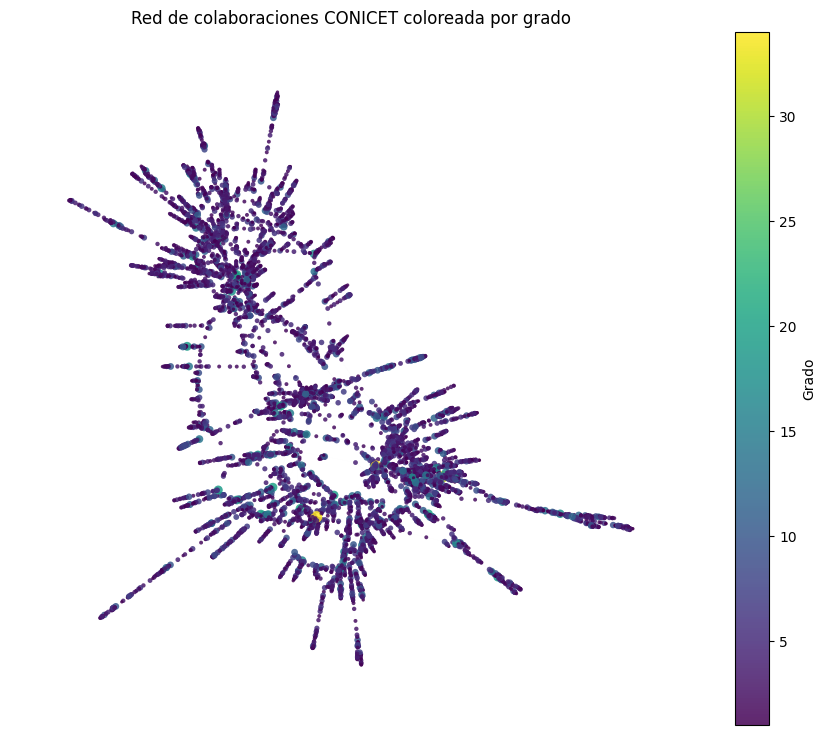

In [18]:
# Visualizaci?n completa usando posiciones precalculadas.
node_order = [n for n in C_clean.nodes() if n in pos_conicet]
node_degrees = np.array([degrees[n] for n in node_order])
node_sizes = 6 + 65 * (node_degrees - node_degrees.min()) / (node_degrees.max() - node_degrees.min())

plt.figure(figsize=(11, 9))
nx.draw_networkx_edges(C_clean, pos_conicet, alpha=0.025, width=0.25, edge_color="gray")
nodes = nx.draw_networkx_nodes(
    C_clean,
    pos_conicet,
    nodelist=node_order,
    node_size=node_sizes,
    node_color=node_degrees,
    cmap="viridis",
    alpha=0.85,
    linewidths=0,
)
plt.colorbar(nodes, label="Grado")
plt.title("Red de colaboraciones CONICET coloreada por grado")
plt.axis("off")
plt.show()

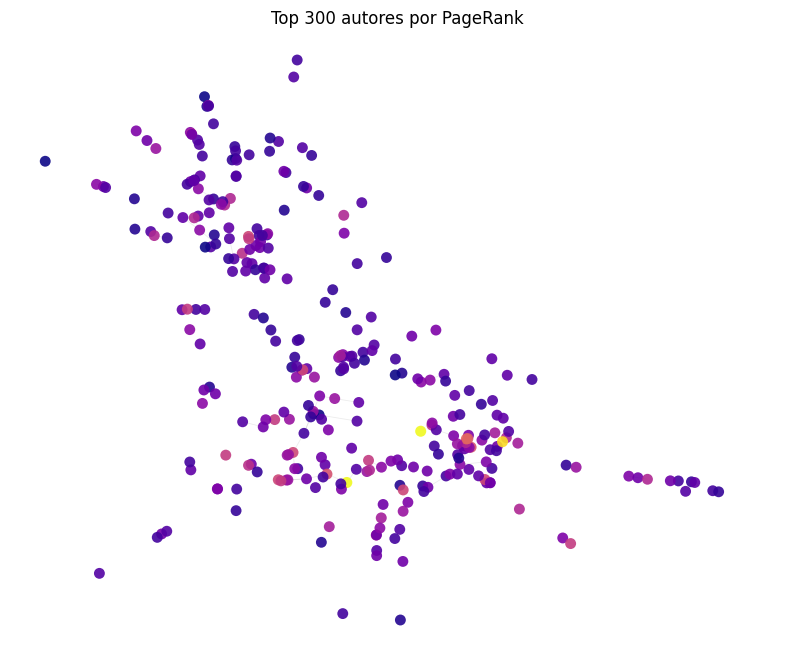

In [19]:
# Subgrafo de nodos m?s centrales por PageRank para una visualizaci?n m?s legible.
top_nodes = centrality_df.sort_values("pagerank", ascending=False).head(300)["node"].tolist()
C_top = C_clean.subgraph(top_nodes).copy()
pos_top = {n: pos_conicet[n] for n in C_top.nodes() if n in pos_conicet}

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(C_top, pos_top, alpha=0.15, width=0.6, edge_color="gray")
nx.draw_networkx_nodes(
    C_top,
    pos_top,
    node_size=[60 + 3500 * pagerank[n] for n in C_top.nodes() if n in pos_top],
    node_color=[degrees[n] for n in C_top.nodes() if n in pos_top],
    cmap="plasma",
    alpha=0.9,
    linewidths=0,
)
plt.title("Top 300 autores por PageRank")
plt.axis("off")
plt.show()

La visualizaci?n permite observar la estructura topol?gica de las colaboraciones. Los nodos m?s grandes o de colores m?s intensos tienden a representar autores con m?s conexiones o mayor importancia estructural dentro de la red.

**DETECCI?N DE COMUNIDADES**

In [20]:
partition = cl.best_partition(C_clean, weight="weight", random_state=42)
modularity = cl.modularity(partition, C_clean, weight="weight")

communities_df = pd.DataFrame({
    "node": list(partition.keys()),
    "community": list(partition.values()),
    "degree": [degrees[n] for n in partition.keys()],
    "A3": [C_clean.nodes[n].get("A3") for n in partition.keys()],
})

community_sizes = communities_df["community"].value_counts().sort_values(ascending=False)

print("Cantidad de comunidades:", community_sizes.shape[0])
print("Modularidad:", modularity)
community_sizes.head(15).to_frame("cantidad_autores")

Cantidad de comunidades: 100
Modularidad: 0.9718785694612101


,cantidad_autores
community,
0,194
20,179
46,162
37,161
43,159
25,148
53,143
34,141
11,140


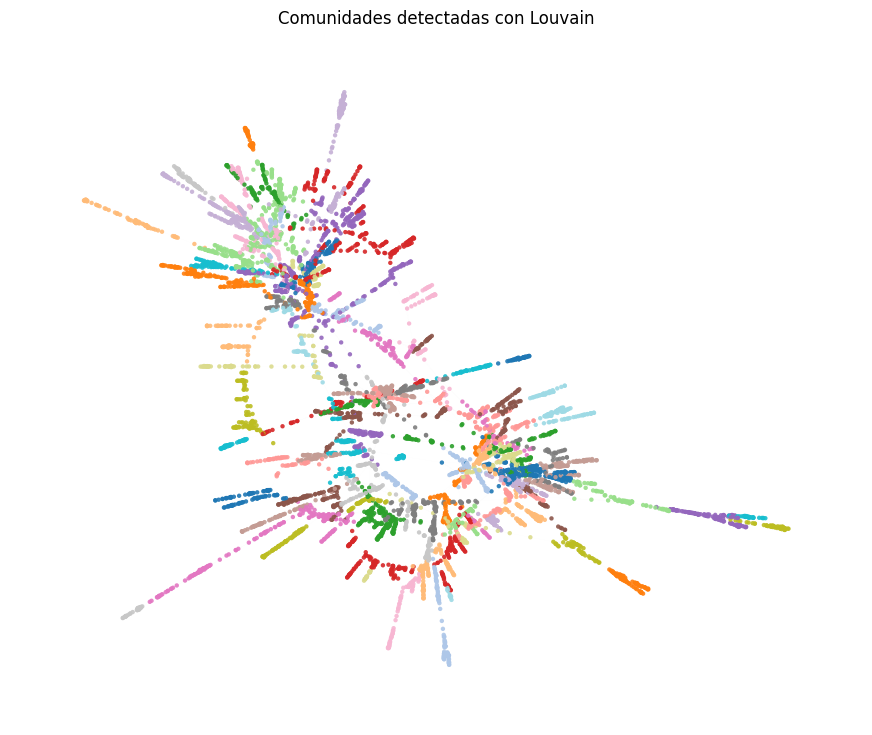

In [21]:
plt.figure(figsize=(11, 9))
colors = [partition[n] for n in C_clean.nodes() if n in pos_conicet]

nx.draw_networkx_edges(C_clean, pos_conicet, alpha=0.02, width=0.25, edge_color="gray")
nx.draw_networkx_nodes(
    C_clean,
    pos_conicet,
    nodelist=[n for n in C_clean.nodes() if n in pos_conicet],
    node_size=10,
    node_color=colors,
    cmap="tab20",
    alpha=0.9,
    linewidths=0,
)
plt.title("Comunidades detectadas con Louvain")
plt.axis("off")
plt.show()

In [22]:
# Cruce entre comunidades y grandes ?reas A3
community_area = pd.crosstab(communities_df["community"], communities_df["A3"])
community_area.loc[community_sizes.head(10).index]

A3,"Biología Marina, Limnología",Ciencias Agrícolas,Ciencias Médicas y de la Salud,Ciencias Naturales Y Exactas,Ciencias Sociales,Humanidades,Ingenierías y Tecnologías
community,,,,,,,
0,0,1,2,187,1,3,0
20,0,39,0,117,9,13,1
46,0,0,0,2,104,56,0
37,0,0,5,35,0,109,12
43,0,0,1,1,68,89,0
25,0,0,3,1,119,25,0
53,0,0,2,6,121,14,0
34,0,0,2,4,82,53,0
11,0,0,0,0,97,43,0


Las comunidades detectadas agrupan autores con m?s v?nculos internos que externos. En una red de coautor?as, estas comunidades pueden reflejar laboratorios, grupos tem?ticos, ?reas disciplinares o colaboraciones institucionales persistentes.

**ROBUSTEZ DE LA RED**

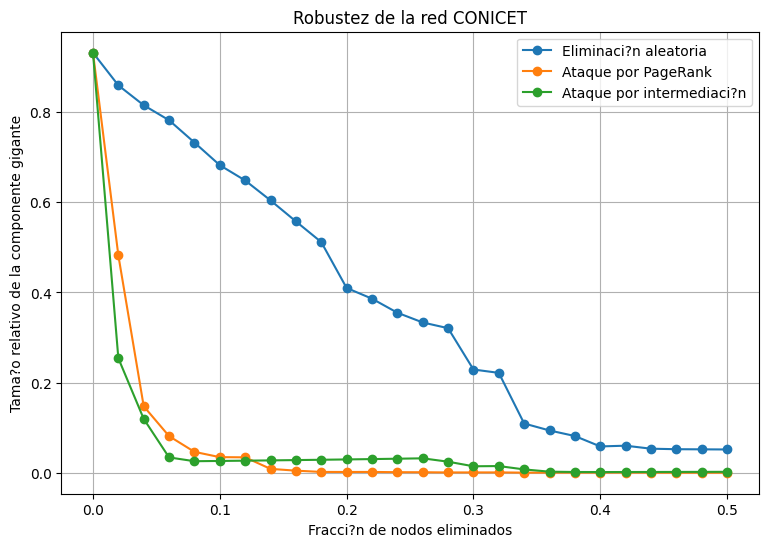

In [23]:
def giant_component_fraction(H):
    if H.number_of_nodes() == 0:
        return 0
    largest = max(nx.connected_components(H), key=len)
    return len(largest) / H.number_of_nodes()

nodes = list(C_clean.nodes())
random_order = nodes.copy()
np.random.shuffle(random_order)

pagerank_order = sorted(pagerank, key=pagerank.get, reverse=True)
betweenness_order = sorted(betweenness, key=betweenness.get, reverse=True)

def robustness_curve(G_base, removal_order, fractions=np.linspace(0, 0.5, 26)):
    results = []
    n = G_base.number_of_nodes()
    for frac in fractions:
        k = int(frac * n)
        H = G_base.copy()
        H.remove_nodes_from(removal_order[:k])
        results.append(giant_component_fraction(H))
    return fractions, results

fractions, curve_random = robustness_curve(C_clean, random_order)
_, curve_pagerank = robustness_curve(C_clean, pagerank_order)
_, curve_betweenness = robustness_curve(C_clean, betweenness_order)

plt.figure(figsize=(9, 6))
plt.plot(fractions, curve_random, marker="o", label="Eliminaci?n aleatoria")
plt.plot(fractions, curve_pagerank, marker="o", label="Ataque por PageRank")
plt.plot(fractions, curve_betweenness, marker="o", label="Ataque por intermediaci?n")
plt.xlabel("Fracci?n de nodos eliminados")
plt.ylabel("Tama?o relativo de la componente gigante")
plt.title("Robustez de la red CONICET")
plt.legend()
plt.show()

La comparaci?n entre eliminaci?n aleatoria y ataques dirigidos permite evaluar la vulnerabilidad estructural de la red. Si la componente gigante cae m?s r?pido al remover autores centrales o autores puente, entonces esos nodos cumplen un rol clave en la conectividad de la red acad?mica.

**COMPARACI?N CON RED ALEATORIA**

In [24]:
N = C_clean.number_of_nodes()
E = C_clean.number_of_edges()
p_er = (2 * E) / (N * (N - 1))

C_er = nx.erdos_renyi_graph(N, p_er, seed=42)
C_er_gc = C_er.subgraph(max(nx.connected_components(C_er), key=len)).copy()

def metricas_comparativas(H, H_gc):
    return {
        "nodos": H.number_of_nodes(),
        "aristas": H.number_of_edges(),
        "grado_promedio": np.mean([d for _, d in H.degree()]),
        "clustering_promedio": nx.average_clustering(H),
        "transitividad": nx.transitivity(H),
        "asortatividad": nx.degree_assortativity_coefficient(H),
        "distancia_media_gc": nx.average_shortest_path_length(H_gc),
        "diametro_gc": nx.diameter(H_gc),
    }

comparison = pd.DataFrame({
    "CONICET": metricas_comparativas(C_clean, C_main),
    "Erdos-Renyi": metricas_comparativas(C_er, C_er_gc),
})

comparison

,CONICET,Erdos-Renyi
nodos,8288.000000,8288.000000
aristas,14105.000000,14017.000000
grado_promedio,3.403716,3.382481
clustering_promedio,0.575300,0.000365
transitividad,0.358053,0.000380
asortatividad,-0.027752,0.001629
distancia_media_gc,19.596953,7.451871
diametro_gc,52.000000,18.000000


La red aleatoria de Erd?s-R?nyi conserva aproximadamente el tama?o y la densidad esperada, pero no necesariamente reproduce los patrones de colaboraci?n cient?fica. Si la red CONICET muestra mayor clustering, modularidad o asortatividad distinta, entonces la estructura observada responde a organizaci?n disciplinar, comunidades acad?micas y colaboraciones reales, no solo al azar.

**CONCLUSIONES**

El dataset de CONICET representa una red de coautor?as entre investigadores o autores de publicaciones 2023-2024. A diferencia de una red puramente social, incorpora metadatos disciplinares (`A1`, `A2`, `A3`) y un peso de colaboraci?n que permite analizar tanto cantidad de v?nculos como intensidad de colaboraci?n.

El an?lisis de componente gigante, m?tricas globales, centralidades y comunidades permite identificar autores centrales, posibles puentes entre ?reas y agrupamientos tem?ticos. La comparaci?n con una red aleatoria ayuda a evaluar si la estructura observada puede explicarse por densidad o si responde a patrones propios de la producci?n cient?fica.

La robustez aporta una lectura adicional: la red puede tolerar la p?rdida aleatoria de autores, pero puede fragmentarse m?s r?pido si se remueven nodos con alta centralidad o alta intermediaci?n.